<a href="https://colab.research.google.com/github/jjmoncus/MV_coursework_2/blob/main/Machine_Vision_Final_Lab_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Dependencies

In [4]:
import torch
import gc

# 1. Delete heavy variables
if 'model' in locals(): del model
if 'data' in locals(): del data

# 2. Trigger Python's garbage collector
gc.collect()

# 3. Clear the specific GPU cache
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    torch.cuda.empty_cache()

In [5]:
# change all these to !pip later
%pip install boto3 -q
%pip install opencv-python torch numpy torchvision
%pip install seaborn
%pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import os
import cv2
import numpy as np

## Download the data

The data for this assignment has been made available and is downloadable to disk by running the below cell.

In [277]:
# import boto3
# from botocore import UNSIGNED
# from botocore.config import Config
# import os

# # Connect to S3 without authentication (public bucket)
# s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# bucket_name = 'prism-mvta'
# prefix = 'training-and-validation-data/'
# download_dir = './video-data'

# os.makedirs(download_dir, exist_ok=True)

# # List all objects in the S3 path
# paginator = s3.get_paginator('list_objects_v2')
# pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

# video_names = []

# for page in pages:
#     if 'Contents' not in page:
#         print("No files found at the specified path! Go and complain to the TAs!")
#         break

#     for obj in page['Contents']:
#         key = obj['Key']
#         filename = os.path.basename(key)

#         if not filename:
#             continue

#         video_names.append(filename)

#         local_path = os.path.join(download_dir, filename)
#         print(f"Downloading: {filename}")
#         s3.download_file(bucket_name, key, local_path)

# print("\n" + "="*50)
# print("Downloaded videos:")
# print("="*50)
# for name in video_names:
#     print(name)

# print(f"\nTotal: {len(video_names)} files")

# Create your Datasets and Dataloaders

Some example code for approaching the first *two* TODOs is given below just to get you started. No starter code is given for the third TODO.

Note, the below code is very rough skeleton code. Make no assumptions as to the correct manner to architect your model based on the structure of this code.

Please feel free to (if not encouraged to) change every single line of the below code (change it to best suit your chosen model architecture, in the next section).

### TODO 1 (This is mostly already done for you - Please see the v1 provided below)

Each video in the folder is prefixed by a number. That number corresponds to the number of distinct pushups visible in the video. Write code to iterate over each video in the folder, and extract the corresponding target associated with the video.

### TODO 2 (This is also mostly already done for you - Please see the v1 provided below)


Divide the data into training and validation sets.

Optionally, you can also create out your own test set to assess your performance.

### TODO 3

Any preprocessing or augmentation of your data which you deem required, should (probably) go here. You are also free to include your data-augmentation code later, though doing it before creating your dataloaders is probably a good idea.

If you complete this TODO, to maintain experimental hygiene, feel free to modify the code which was provided for TODOs 1 and 2.

In [278]:
# Here is a basic implementation of the above two TODOs. You can assume the first TODO is completed correctly.
# Please modify this code to suit you best, as you decide on your preferred model architecture.
# For example, below here we are padding every video to 1,000 frames. That may or may not be a good idea.


class VideoDataset(Dataset):
    """Dataset for loading videos from a folder. Labels from filename prefix."""

    def __init__(self, video_dir, frame_size=(224, 224), transform=None):
        self.video_dir = video_dir
        self.frame_size = frame_size
        self.transform = transform

        self.video_files = [
            f for f in os.listdir(video_dir)
            if f.endswith(('.mp4', '.avi', '.mov'))
        ]

        self.labels = [
            int(f.split('_')[0]) for f in self.video_files
        ]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = os.path.join(self.video_dir, self.video_files[idx])
        frames = self._load_video(video_path)
        label = self.labels[idx]

        if self.transform:
            frames = self.transform(frames)

        return frames, label

    def _load_video(self, path, stride = 5, max_frames = 200):
        cap = cv2.VideoCapture(path)
        frames = []
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # only add every `stride`'th frame
            if frame_count % stride == 0:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.frame_size[1], self.frame_size[0]))
                frames.append(frame)

            frame_count +=1

            if len(frames) == max_frames:
                break

        cap.release()

        frames = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float() / 255

        return frames


def collate_fn(batch):
    frames_list, labels = zip(*batch)
    target_frames = 200  # Updated to your requested 200

    padded_frames = []
    for frames in frames_list:
        # frames shape: (Channels, Time, Height, Width)
        num_frames = frames.shape[1]
        
        if num_frames < target_frames:
            # 1. Grab the last frame: (C, 1, H, W)
            last_frame = frames[:, -1:, :, :]
            
            # 2. Calculate how many times to repeat it
            padding_size = target_frames - num_frames
            
            # 3. Create the padding by repeating the last frame
            padding = last_frame.repeat(1, padding_size, 1, 1)
            
            # 4. Concatenate along the temporal dimension (dim=1)
            frames = torch.cat([frames, padding], dim=1)
            
        elif num_frames > target_frames:
            # Truncate if the video is too long
            frames = frames[:, :target_frames, :, :]
            
        padded_frames.append(frames)

    # Combine list into a single batch tensor: (Batch, C, T, H, W)
    frames_batch = torch.stack(padded_frames, dim=0)
    labels_batch = torch.tensor(labels)

    return frames_batch, labels_batch


def get_dataloaders(video_dir, batch_size=5, val_split=0.2, collate_fn = None):
    """Create train and validation dataloaders."""

    full_dataset = VideoDataset(video_dir)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"Train: {len(train_dataset)} videos, Val: {len(val_dataset)} videos\n")

    return train_loader, val_loader

# Create a Model

For this assignment, we request you use PyTorch. Below is an example of how to instantiate a very basic PyTorch model.

Note, this model below needs a _lot_ of work.

Please include your code for creating your model below.

The only constraint here is that you define a Python object which inherits from a PyTorch nn.Module object. Beyond that, please feel free to implement anything you like: Transformer, Vision Transformer, MLP, CNN, etc.

### TODO 4

Create your model.

In [279]:
# import torch
# import torch.nn as nn
# # from huggingface_hub import HfApi, hf_hub_download


# class SimpleVideoClassifier(nn.Module):
#     def __init__(self):
#         super().__init__()
        

#         # convolution block on centroids array
#         self.conv = nn.Sequential(
            
#             nn.Conv1d(2, 16, kernel_size = 5, padding = 2),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size = 2), # 100 frames --> 50 frames

#             nn.Conv1d(16, 32, kernel_size = 3, padding = 1),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1) # 50 frames --> 1 "frame"
#         )

#         # Linear layers
#         self.fc1 = nn.Linear(32, 1)

#     def forward(self, x):
#         # rearrange dimensions (B, T, C, H, W)
#         x_perm = x.permute(0, 2, 1, 3, 4)
#         B, T, C, H, W = x_perm.shape

#         # convert to centroids (B x T x 2)
#         h1 = torch.stack([get_trunk_centroids(v) for v in x_perm])
#         h1 = h1.to(torch.float32)

#         # normalizer = torch.tensor([W, H], device=h1.device, dtype=torch.float32)
#         # h1_norm = h1 / normalizer

#         h1_t = h1.transpose(1, 2)
#         h2 = self.conv(h1_t)
#         h2_flat = torch.flatten(h2, 1)
#         h3 = self.fc1(h2_flat)
#         # h4 = self.fc2(h3)

#         return h3


# First Attempt, no centroids calculation

**Update**, vanishing gradients, consistently just predicts the mean

In [280]:
# class VideoConvModel(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         # Spatial Features
#         # We can use a tiny custom CNN or a pre-trained ResNet18
#         self.spatial_features = nn.Sequential(
#             nn.Conv2d(3, 6, kernel_size=3, stride=2, padding=1), # 3x224x224 --> 6x112x112
#             nn.ReLU(),
#             # nn.MaxPool2d(2),
#             nn.Conv2d(6, 12, kernel_size=3, stride=2, padding=1), #6x112x112 --> 12x56x56
#             nn.ReLU(),
#             # nn.MaxPool2d(2),
#             nn.Conv2d(12, 18, kernel_size=3, stride=2, padding=1), #12x56x56 --> 18x28x28
#             nn.ReLU(),
#             nn.Conv2d(18, 24, kernel_size=3, stride=2, padding=1), #18x28x28 --> 24x14x14
#             nn.ReLU(),
#             nn.Conv2d(24, 32, kernel_size=3, stride=2, padding=1), #24x14x14 --> 32x7x7
#             nn.ReLU(),
#             nn.Conv2d(32, 40, kernel_size=3, stride=2, padding=1), #32x7x7 --> 40x4x4
#             nn.ReLU(),
#             nn.Flatten(), # Becomes 40 * 4 * 4 = 640
#             nn.Linear(640, 2) # 640x1x1 -> 2x1x1
#             # nn.ReLU()
#         )

#         # Temporal Processor
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(2, 6, kernel_size = 3, stride = 2, padding = 1), # 100x2x1x1 frames --> 50x6x1x1 frames
#             nn.ReLU(),
#             nn.Conv1d(6, 12, kernel_size = 3, stride = 2, padding = 1), # 50x6x1x1 frames --> 25x12x1x1 frames
#             nn.ReLU(),
#             nn.Conv1d(12, 18, kernel_size = 3, stride = 2, padding = 1), # 25x12x1x1 frames --> 13x18x1x1 frames
#             nn.ReLU()
#         )
        
#         # classifying summary of spatial/temporal info
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(234, 1) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # We want [B*T, C, H, W] for the spatial CNN
#         # Transpose B and C to get [T, B, C, H, W] then flatten T and B
#         x_in = x.transpose(0, 2).reshape(T * B, C, H, W) 
#         features = self.spatial_features(x_in) # [B*T, 32, 1, 1]
        
#         # Reshape back to separate Time and Batch
#         features = features.reshape(B, T, -1).transpose(1, 2) # [B, 2, T]
        
#         # Run temporal convolutions
#         combined = self.temporal_conv(features).squeeze(-1) # [B, 64]
#         return self.classifier(combined)

# Second attempt, healthier model
Our model is just predicting the mean of each batch, which signals a vanishing gradients problem
Let's help the model pass more gradients by:
- Batch Normalization
- removing the linear bottleneck at the end of 
- increasing number of channels early in the spatial convolutions

**UPDATE** results in bad gradients (likely vanishing) consistently just predicts the mean

In [281]:
# class VideoConvModel(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         # Spatial Features
#         # We can use a tiny custom CNN or a pre-trained ResNet18
#         self.spatial_features = nn.Sequential(
#             nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1), # 3x224x224 --> 6x112x112
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
#             nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), #6x112x112 --> 12x56x56
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), #12x56x56 --> 18x28x28
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), #18x28x28 --> 24x14x14
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), #24x14x14 --> 32x7x7
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), #32x7x7 --> 40x4x4
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Flatten(), # Becomes 128 * 4 * 4 = 640
#             nn.Linear(128 * 4 * 4, 64) # largex1x1 -> 64x1x1
#             # nn.ReLU()
#         )

#         # Temporal Processor
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(64, 64, kernel_size = 3, stride = 2, padding = 1), # 100x64x1x1 frames --> 50x64x1x1 frames
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size = 3, stride = 2, padding = 1), # 50x64x1x1 frames --> 25x128x1x1 frames
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Conv1d(128, 128, kernel_size = 3, stride = 2, padding = 1), # 25x128x1x1 frames --> 13x128x1x1 frames
#             nn.BatchNorm1d(128),
#             nn.ReLU()
#         )
        
#         # classifying summary of spatial/temporal info
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(1664, 1) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # We want [B*T, C, H, W] for the spatial CNN
#         # Transpose B and C to get [T, B, C, H, W] then flatten T and B
#         x_in = x.transpose(0, 2).reshape(T * B, C, H, W) 
#         features = self.spatial_features(x_in) # [B*T, 32, 1, 1]
        
#         # Reshape back to separate Time and Batch
#         features = features.reshape(B, T, -1).transpose(1, 2) # [B, 2, T]
        
#         # Run temporal convolutions
#         combined = self.temporal_conv(features).squeeze(-1) # [B, 64]
#         return self.classifier(combined)

# Third attempt, removing another bottleneck:
- The final linear classifier bottleneck scares me, trying to make it less aggressive.
- Also, three frames seems too fine-grained of a temporal kernel to actually see any push-up movement, gonna expand it to 5 and make stride larger

**Update** still have a gradients problem - very often just predict the mean of the batch

In [282]:
# class VideoConvModel(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         # Spatial Features
#         # We can use a tiny custom CNN or a pre-trained ResNet18
#         self.spatial_features = nn.Sequential(
#             nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1), # 3x224x224 --> 6x112x112
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
#             nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), #6x112x112 --> 12x56x56
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), #12x56x56 --> 18x28x28
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), #18x28x28 --> 24x14x14
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), #24x14x14 --> 32x7x7
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), #32x7x7 --> 40x4x4
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Flatten(), # Becomes 128 * 4 * 4 = 640
#             nn.Linear(128 * 4 * 4, 64), # largex1x1 -> 64x1x1
#             nn.ReLU()
#         )

#         # Temporal Processor
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(64, 64, kernel_size = 5, stride = 3, padding = 2), # 100x64x1x1 frames --> 33x64x1x1 frames
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Conv1d(64, 128, kernel_size = 5, stride = 3, padding = 2), # 33x64x1x1 frames --> 11x128x1x1 frames
#             nn.BatchNorm1d(128),
#             nn.ReLU(),
#             nn.Conv1d(128, 128, kernel_size = 5, stride = 3, padding = 2), # 11x128x1x1 frames --> 4x128x1x1 frames
#             nn.BatchNorm1d(128),
#             nn.ReLU()
#         )
        
#         # classifying summary of spatial/temporal info
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(512, 1) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # We want [B*T, C, H, W] for the spatial CNN
#         # Transpose B and C to get [T, B, C, H, W] then flatten T and B
#         x_in = x.transpose(0, 2).reshape(T * B, C, H, W) 
#         features = self.spatial_features(x_in) # [B*T, 32, 1, 1]
        
#         # Reshape back to separate Time and Batch
#         features = features.reshape(B, T, -1).transpose(1, 2) # [B, 2, T]
        
#         # Run temporal convolutions
#         combined = self.temporal_conv(features) # [B, 64]
#         return self.classifier(combined)

# Fourth attempt - switching to Resnet
- trying to solve the vanishing gradients problem

**Update**, does well on training, not so much on test (overfitting)

In [283]:
# import torch
# import torch.nn as nn
# from torchvision import models

# class VideoResNetModel(nn.Module):
#     def __init__(self, use_pretrained=True):
#         super().__init__()
        
#         # 1. Load Pre-trained ResNet18
#         # weights=models.ResNet18_Weights.DEFAULT is the modern way to load pre-trained
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        
#         # 2. Extract the feature extractor (all layers except the final fc layer)
#         # ResNet18's final layer before the classifier is an Global Average Pool
#         # which outputs 512 features.
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         for param in self.backbone.parameters():
#             param.requires_grad = False  # Gradients are no longer calculated/stored
        
#         # 3. Optional: Freeze the backbone if you have a small dataset
#         # for param in self.backbone.parameters():
#         #     param.requires_grad = False

#         # 4. Temporal Processor
#         # ResNet18 (after Global Average Pool) outputs 512 features per frame.
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(512, 128, kernel_size=3, stride=2, padding=1), # 100 -> 50
#             nn.BatchNorm1d(128),
#             nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
#             nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 50 -> 25
#             nn.BatchNorm1d(64),
#             nn.LeakyReLU(0.1),
#             nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 25 -> 13
#             nn.BatchNorm1d(32),
#             nn.LeakyReLU(0.1)
#         )
        
#         # 5. Classifier
#         # Output of temporal is [B, 32, 13]. Flattened = 32 * 13 = 416
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(416, 1) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # Reshape for Spatial: [B*T, C, H, W]
#         x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
#         # Pass through ResNet backbone
#         # Output is [B*T, 512, 1, 1]
#         spatial_features = self.backbone(x_in) 
        
#         # Reshape for Temporal: [B, 512, T]
#         temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
#         # Temporal Conv
#         temporal_out = self.temporal_conv(temporal_in)
        
#         # Classify
#         return self.classifier(temporal_out)

# Fifth attempt (coming back to this)

adding transformations to the input data so our training dataset grows

In [284]:
# # Redefine dataloaders function to include transformations
# def get_dataloaders(video_dir, batch_size = 5, val_split = 0.2, collate_fn = None):
#     """Create train and validation dataloaders."""

#     # applying train_transform to the full dataset is naive I think
#     full_dataset = VideoDataset(video_dir, transform = train_transform)

#     val_size = int(len(full_dataset) * val_split)
#     train_size = len(full_dataset) - val_size

#     train_dataset, val_dataset = random_split(
#         full_dataset,
#         [train_size, val_size],
#         generator=torch.Generator().manual_seed(42)
#     )

#     train_loader = DataLoader(
#         train_dataset,
#         batch_size=batch_size,
#         shuffle=True,
#         num_workers=0,
#         collate_fn=collate_fn
#     )

#     val_loader = DataLoader(
#         val_dataset,
#         batch_size=batch_size,
#         shuffle=False,
#         num_workers=0,
#         collate_fn=collate_fn
#     )

#     print(f"Train: {len(train_dataset)} videos, Val: {len(val_dataset)} videos\n")

#     return train_loader, val_loader

# Fifth attempt: preventing overfitting
- adding weight decay in the optimizer
- unfreezing last layer of resnet backbone

In [285]:
# import torch
# import torch.nn as nn
# from torchvision import models

# class VideoResNetModel(nn.Module):
#     def __init__(self, use_pretrained=True):
#         super().__init__()
        
#         # 1. Load Pre-trained ResNet18
#         # weights=models.ResNet18_Weights.DEFAULT is the modern way to load pre-trained
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        
#         # 2. Extract the feature extractor (all layers except the final fc layer)
#         # ResNet18's final layer before the classifier is an Global Average Pool
#         # which outputs 512 features.
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         for param in self.backbone.parameters():
#             param.requires_grad = False  # Gradients are no longer calculated/stored

#         # for name, child in self.backbone.named_children():
#         #     if name == '7': # In a Sequential(resnet_children[:-1]), layer4 is index 7
#         #         print("Unfreezing Layer 4...")
#         #         for param in child.parameters():
#         #             param.requires_grad = True
                
#         # 3. Optional: Freeze the backbone if you have a small dataset
#         # for param in self.backbone.parameters():
#         #     param.requires_grad = False

#         # 4. Temporal Processor
#         # ResNet18 (after Global Average Pool) outputs 512 features per frame.
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(512, 128, kernel_size=3, stride=2, padding=1), # 100 -> 50
#             nn.BatchNorm1d(128),
#             nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
#             nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 50 -> 25
#             nn.BatchNorm1d(64),
#             nn.LeakyReLU(0.1),
#             nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 25 -> 13
#             nn.BatchNorm1d(32),
#             nn.LeakyReLU(0.1)
#         )
        
#         # 5. Classifier
#         # Output of temporal is [B, 32, 13]. Flattened = 32 * 13 = 416
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(416, 1) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # Reshape for Spatial: [B*T, C, H, W]
#         x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
#         # Pass through ResNet backbone
#         # Output is [B*T, 512, 1, 1]
#         spatial_features = self.backbone(x_in) 
        
#         # Reshape for Temporal: [B, 512, T]
#         temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
#         # Temporal Conv
#         temporal_out = self.temporal_conv(temporal_in)
        
#         # Classify
#         return self.classifier(temporal_out)

# Sixth Attempt: Trying transformations on the data
- implement base transformations
- wrap transformation implementation in a class which guarantees transforms are applied uniformly across each frame in a time-series
- lowering learning rate, and slightly raising weight decay
- monitoring weight norms, to see if weights explode or vanish
- training for MANY more epochs (60), and saving the best model across all epochs to use later

In [8]:
import random
import torchvision.transforms as T

# ## transformations (Copied from Practical 9)
# train_transform = T.Compose([
    
#     T.Resize( (224, 224) ),
#     T.RandomCrop(150), 
    
#     T.RandomHorizontalFlip(p = .1),
#     T.RandomVerticalFlip(p = .1),
#     T.RandomRotation(degrees = 10), 
    
#     T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    
#     # T.ToTensor(),

#     T.Normalize(mean = [ 0.485, 0.456, 0.406 ],std = [ 0.229, 0.224, 0.225 ])
# ])

# val_transform = T.Compose([
    
#     T.Resize( (224, 224) ),
#     T.CenterCrop(150), 
#     # T.ToTensor(),
#     T.Normalize(mean = [ 0.485, 0.456, 0.406 ],std = [ 0.229, 0.224, 0.225 ]) 
# ])

# class to ensure transformations are applied uniformly across the time axis
class TemporalUniformTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, video_frames):
        """
        video_frames: A list of PIL Images or a 4D Tensor [T, C, H, W]
        """
        # 1. Generate a single random seed for this entire video clip
        seed = random.randint(0, 2**32)
        
        video_frames = torch.unbind(video_frames, dim = 1)

        transformed_frames = []
        
        for frame in video_frames:
            # 2. Synchronize all random engines to the same seed for this frame
            random.seed(seed)
            torch.manual_seed(seed)
            np.random.seed(seed)
            
            # 3. Apply the transform (it will now pick the same 'random' values)
            transformed_frames.append(self.transform(frame))
            
        # 4. Stack back into a 4D tensor [C, T, H, W] for the model
        return torch.stack(transformed_frames, dim=1)


# new class so a different transform can be applied to each dataset (train vs val)
class ApplyTransform(Dataset):
    """A small wrapper to apply a specific transform to a dataset subset."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# redefine dataloaders with transforms correctly appleid to train and val
def get_dataloaders(video_dir, batch_size=5, val_split=0.2, train_transform=None, val_transform=None, collate_fn=None):
    
    # 1. Initialize dataset WITHOUT a transform initially
    full_dataset = VideoDataset(video_dir, transform=None)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size

    # 2. Split the raw data
    train_subset, val_subset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # 3. Wrap subsets with their respective transforms
    train_dataset = ApplyTransform(train_subset, transform=train_transform)
    val_dataset = ApplyTransform(val_subset, transform=val_transform)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
    )

    return train_loader, val_loader

# function for calculating Euclidean norm of all model weights
def get_model_weight_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.requires_grad:
            # L2 Norm: square the values, sum them, and take the square root
            param_norm = p.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

# Seventh attempt
- the original transformations were likely too difficult. Let's try easier ones

In [287]:
# train_transform = T.Compose([
    
#     T.Resize((240, 240)), 
#     T.RandomCrop(224), 
    
#     T.RandomHorizontalFlip(p=0.5), 
#     T.RandomRotation(degrees=5), # Reduced from 10 to 5
    
#     T.ColorJitter(brightness=0.05, contrast=0.05),
    
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# # VALIDATION: Deterministic & Clean
# val_transform = T.Compose([
    
#     T.Resize((224, 224)), 
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
# ])

# Eighth attempt
- let's remove the video transformations, since they seem to be making things worse
- let's change the problem to classification and see if the model has an easier time

In [288]:
# import torch
# import torch.nn as nn
# from torchvision import models

# class VideoResNetModel(nn.Module):
#     def __init__(self, use_pretrained=True, num_classes = 10):
#         super().__init__()
        
#         # 1. Load Pre-trained ResNet18
#         # weights=models.ResNet18_Weights.DEFAULT is the modern way to load pre-trained
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        
#         # 2. Extract the feature extractor (all layers except the final fc layer)
#         # ResNet18's final layer before the classifier is an Global Average Pool
#         # which outputs 512 features.
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         for param in self.backbone.parameters():
#             param.requires_grad = False  # Gradients are no longer calculated/stored

#         # for name, child in self.backbone.named_children():
#         #     if name == '7': # In a Sequential(resnet_children[:-1]), layer4 is index 7
#         #         print("Unfreezing Layer 4...")
#         #         for param in child.parameters():
#         #             param.requires_grad = True
                
#         # 3. Optional: Freeze the backbone if you have a small dataset
#         # for param in self.backbone.parameters():
#         #     param.requires_grad = False

#         # 4. Temporal Processor
#         # ResNet18 (after Global Average Pool) outputs 512 features per frame.
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(512, 128, kernel_size=3, stride=2, padding=1), # 100 -> 50
#             nn.BatchNorm1d(128),
#             nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
#             nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 50 -> 25
#             nn.BatchNorm1d(64),
#             nn.LeakyReLU(0.1),
#             nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 25 -> 13
#             nn.BatchNorm1d(32),
#             nn.LeakyReLU(0.1)
#         )
        
#         # 5. Classifier
#         # Output of temporal is [B, 32, 13]. Flattened = 32 * 13 = 416
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(416, num_classes) 
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # Reshape for Spatial: [B*T, C, H, W]
#         x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
#         # Pass through ResNet backbone
#         # Output is [B*T, 512, 1, 1]
#         spatial_features = self.backbone(x_in) 
        
#         # Reshape for Temporal: [B, 512, T]
#         temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
#         # Temporal Conv
#         temporal_out = self.temporal_conv(temporal_in)
        
#         # Classify
#         return self.classifier(temporal_out)

# Ninth attempt:
- previous attempt was best so far (61% final val error)
- replace 1D convs with transformer arch for temporal processing

In [289]:
# import torch
# import torch.nn as nn
# from torchvision import models

# class VideoTransformerModel(nn.Module):
#     def __init__(self, use_pretrained=True, num_classes = 10, num_frames = 100):
#         super().__init__()
        
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         for param in self.backbone.parameters():
#             param.requires_grad = False  # Gradients are no longer calculated/stored

    
#         # Temporal Processor
#         # ResNet18 (after Global Average Pool) outputs 512 features per frame.
#         self.d_model = 512  # ResNet18 output size
#         self.nhead = 4      # Number of attention heads
#         self.num_layers = 2 # Number of transformer layers
        
#         # 3. Positional Encoding & CLS Token
#         # We need a learnable position embedding for the 100 frames + 1 for the CLS token
#         self.pos_embedding = nn.Parameter(torch.zeros(1, num_frames + 1, self.d_model))
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, self.d_model))
        
#         # 4. Temporal Transformer Encoder
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model = self.d_model, 
#             nhead = self.nhead,
#             dim_feedforward = 1024,
#             dropout = 0.1,
#             batch_first = True # This makes input shape (Batch, Seq, Features)
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers = self.num_layers)
        
        
#         self.classifier = nn.Linear(self.d_model, num_classes)

#     def forward(self, x):
        
#         B, C, T, H, W = x.shape
#         x_in = x.transpose(1, 2).reshape(B * T, C, H, W)    # Reshape for Spatial: [B*T, C, H, W]
#         spatial_features = self.backbone(x_in)              # Output is [B*T, 512, 1, 1]
        
#         # Reshape for Temporal: [B, 512, T]
#         temporal_in = spatial_features.view(B, T, self.d_model)
        
#         # Prepend CLS token to the sequence
#         # cls_tokens shape: [B, 1, 512]
#         cls_tokens = self.cls_token.expand(B, -1, -1)
#         x = torch.cat((cls_tokens, temporal_in), dim=1) # [B, T+1, 512]
        
#         # Add Positional Encoding
#         x = x + self.pos_embedding
        
#         # Transformer Pass
#         # x shape: [B, T+1, 512]
#         transformer_out = self.transformer(x)
        
#         # We take only the first token (the CLS token) which now contains 
#         # the "summary" of the whole temporal sequence
#         sequence_summary = transformer_out[:, 0] # [B, 512]
        
#         return self.classifier(sequence_summary)

# Tenth attempt
- going back to pre-transformer architecture, 
- more layers to increase capacity
- training for longer, with some weight decay to combat overfitting


In [290]:
# import torch
# import torch.nn as nn
# from torchvision import models

# class VideoResNetModel(nn.Module):
#     def __init__(self, use_pretrained=True, num_classes = 10):
#         super().__init__()
        
#         resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
#         self.backbone = nn.Sequential(*list(resnet.children())[:-1])
#         for param in self.backbone.parameters():
#             param.requires_grad = False  # Gradients are no longer calculated/stored

#         # Temporal Processor
#         # ResNet18 (after Global Average Pool) outputs 512 features per frame.
#         # added one more convolutional layer than before
#         self.temporal_conv = nn.Sequential(
#             nn.Conv1d(512, 256, kernel_size=3, stride=2, padding=1), # 100 -> 50
#             nn.BatchNorm1d(256),
#             nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
#             nn.Conv1d(256, 128, kernel_size=3, stride=2, padding=1), # 50 -> 25
#             nn.BatchNorm1d(128),
#             nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
#             nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 25 -> 13
#             nn.BatchNorm1d(64),
#             nn.LeakyReLU(0.1),
#             nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 13 -> 7
#             nn.BatchNorm1d(32),
#             nn.LeakyReLU(0.1)
#         )
        
#         # 5. Classifier
#         # Output of temporal is [B, 32, 13]. Flattened = 32 * 7 = 224
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(224, 112),
#             nn.LeakyReLU(0.1),
#             nn.Linear(112, num_classes),
#         )

#     def forward(self, x):
#         # x: [B, C, T, H, W]
#         B, C, T, H, W = x.shape
        
#         # Reshape for Spatial: [B*T, C, H, W]
#         x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
#         # Pass through ResNet backbone
#         # Output is [B*T, 512, 1, 1]
#         spatial_features = self.backbone(x_in) 
        
#         # Reshape for Temporal: [B, 512, T]
#         temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
#         # Temporal Conv
#         temporal_out = self.temporal_conv(temporal_in)
        
#         # Classify
#         return self.classifier(temporal_out)

# Eleventh attempt
- overfit a lot on pevious (94% train acc, 75% test acc)
- adding small dropouts to both final classifier head and temporal layers
(still seems to be decently overfitting after 14 epochs)
- bringing back data augmentation (lighter now)
- adding adaptive max pooling to end of temporal layer

In [28]:
import torch
import torch.nn as nn
from torchvision import models

class VideoResNetModel(nn.Module):
    def __init__(self, use_pretrained=True, num_classes = 10):
        super().__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.backbone.parameters():
            param.requires_grad = False  # Gradients are no longer calculated/stored

        # Temporal Processor
        # ResNet18 (after Global Average Pool) outputs 512 features per frame.
        # added one more convolutional layer than before
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, stride=2, padding=1), # 100 -> 50
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(256, 128, kernel_size=3, stride=2, padding=1), # 50 -> 25
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 25 -> 13
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout1d(p = .2),
            nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 13 -> 7
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool1d(1) # sqashes to 1 "frame"
        )
        
        # 5. Classifier
        # Output of temporal is [B, 32, 13]. Flattened = 32 * 1 = 32
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(112, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(112, num_classes),
        )

    def forward(self, x):
        # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        
        # Reshape for Spatial: [B*T, C, H, W]
        x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
        # Pass through ResNet backbone
        # Output is [B*T, 512, 1, 1]
        spatial_features = self.backbone(x_in) 
        
        # Reshape for Temporal: [B, 512, T]
        temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
        # Temporal Conv
        temporal_out = self.temporal_conv(temporal_in)
        
        # Classify
        return self.classifier(temporal_out)

# # more tepid transformations now (no horizontal flip, more color jitter)
# train_transform = T.Compose([
    
#     T.Resize((240, 240)), 
#     T.RandomCrop(224), 
    
#     T.RandomRotation(degrees=5), # Reduced from 10 to 5
    
#     T.ColorJitter(brightness=0.2, contrast=0.2, saturation = .1),
    
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# # VALIDATION: Deterministic & Clean
# val_transform = T.Compose([
    
#     T.Resize((224, 224)), 
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
# ])

# Twelfth attempt
- trying to make the dataset larger and acheiving class balance in the training data:
 - take all videos with 2, cut them in half, save them down with label 1
 - take all videos with 3-5 pushups, stitch temporally with itself, label 6, 8, and 10.
 - take all videos with 4, stitch 75% of frames at the end, label with 7
 - take all videos with 3, stitch twice against itself, label with 9.


When stitching videos, we do "palindrome stitching". i.e. stitch a copy of the video _in reverse_. That way there's no jump cut at the moment of the stitch, which may confuse the model as it tracks the movement of the person. 

In [292]:
import cv2
video_paths = [f for f in os.listdir("./video-data") if f.endswith(('.mp4', '.avi', '.mov'))]

### Checking how many frames my original videos are

In [293]:
import os
folder_path = './video-data'
frame_count = []
for video in video_paths:
    path = os.path.join(folder_path, video)
    cap = cv2.VideoCapture(path)
    count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_count.append(count)
    cap.release()

print(sorted(set(frame_count)))
# they go from 91 to 325

[96, 113, 114, 121, 129, 150, 159, 165, 169, 172, 173, 174, 177, 179, 184, 186, 188, 190, 192, 198, 200, 208, 211, 216, 218, 223, 226, 227, 241, 325]


### Checking how many of each label I have
- we have way more 2s, 3s, and 4s than anything else. The goal should be to use them and spread them over more classes

In [294]:
video_paths = [f for f in os.listdir("./video-data") if f.endswith(('.mp4', '.avi', '.mov'))]
labels = [int(f.split('_')[0]) for f in video_paths]
vals, counts = np.unique(labels, return_counts=True)
np.array([vals, counts])

array([[ 1,  2,  3,  4,  5,  6,  7],
       [ 1, 16, 34, 21,  2,  2,  1]])

In [295]:
def double_length(paths, search_dir = "video-data", out_dir = "train-data"):
    
    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = original_label * 2
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"

        cap = cv2.VideoCapture(full_path)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = cap.get(cv2.CAP_PROP_FPS)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        frames = []

        # 1. Read all frames into memory
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        # 2. Write frames Forward (Original)
        for f in frames:
            out.write(f)

        # 3. Write frames Backward (Reversed)
        # [::-1] reverses the list; we skip the very last frame to avoid a double-frame pause
        for f in frames[::-1]:
            out.write(f)

        cap.release()
        out.release()
        print(f"{output_path}: Done! Created a sequence of {len(frames) * 2} frames.")


def triple_length(paths, search_dir = "video-data", out_dir = "train-data"):
    
    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = original_label * 3
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"

        cap = cv2.VideoCapture(full_path)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = cap.get(cv2.CAP_PROP_FPS)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        frames = []

        # 1. Read all frames into memory
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        # 2. Write frames Forward (Original)
        for f in frames:
            out.write(f)

        # 3. Write frames Backward (Reversed)
        # [::-1] reverses the list; we skip the very last frame to avoid a double-frame pause
        for f in frames[::-1]:
            out.write(f)

        # write frames forward again
        for f in frames:
            out.write(f)        

        cap.release()
        out.release()
        print(f"{output_path}: Done! Created a sequence of {len(frames) * 3} frames.")

def three_to_five(paths, search_dir = "video-data", out_dir = "train-data"):

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = 3
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = 5
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"

        cap = cv2.VideoCapture(full_path)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        # 1. Load all frames into a list
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        # 2. Define the cut-off for the palindrome
        # To add 2 pushups to a 3-pushup video, we need 60% of the frames
        # went with 66 to account for some lag before the pushup begins
        cutoff_index = int(len(frames) * 0.66)

        # 3. Write the Original 4 Pushups (Forward)
        for f in frames:
            out.write(f)

        # 4. Write the Palindrome (Reverse)
        # We start from the very end and go backwards until we hit the 75% mark
        # This adds the 3 pushups in reverse
        palindrome_frames = frames[::-1] # Reverse the full list
        clipped_palindrome = palindrome_frames[:cutoff_index]

        for f in clipped_palindrome:
            out.write(f)

        cap.release()
        out.release()

        print(f"{output_path}: Total frames in new video = {len(frames) + len(clipped_palindrome)}")



def four_to_seven(paths, search_dir = "video-data", out_dir = "train-data"):

    for video_path in paths:
    
        full_path = f"{search_dir}/{video_path}"

        original_label = 4
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = 7
        
        output_path = f"{out_dir}/{new_label}_STITCHED_{rest}"

        cap = cv2.VideoCapture(full_path)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        # 1. Load all frames into a list
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        # 2. Define the cut-off for the palindrome
        # To add 3 pushups to a 4-pushup video, we need 75% of the frames
        # went with 80% to account for dead time before first pushup
        cutoff_index = int(len(frames) * 0.80)

        # 3. Write the Original 4 Pushups (Forward)
        for f in frames:
            out.write(f)

        # 4. Write the Palindrome (Reverse)
        # We start from the very end and go backwards until we hit the 75% mark
        # This adds the 3 pushups in reverse
        palindrome_frames = frames[::-1] # Reverse the full list
        clipped_palindrome = palindrome_frames[:cutoff_index]

        for f in clipped_palindrome:
            out.write(f)

        cap.release()
        out.release()

        print(f"{output_path}: Total frames in new video = {len(frames) + len(clipped_palindrome)}")


def cut_in_half(paths, search_dir = "video-data", out_dir = "train-data"):

    for video_path in paths:
        
        full_path = f"{search_dir}/{video_path}"

        original_label = int(video_path.split('_')[0])
        pattern = f"{original_label}_"
        rest = video_path.replace(pattern, "", 1)
        new_label = int(original_label / 2)
        
        cap = cv2.VideoCapture(full_path)

        # Get video properties
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        # Calculate the midpoint
        midpoint = total_frames // 2

        def save_segment(start_frame, end_frame, output_name):
            out = cv2.VideoWriter(output_name, fourcc, fps, (width, height))
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
            
            for i in range(start_frame, end_frame):
                ret, frame = cap.read()
                if not ret:
                    break
                out.write(frame)
            out.release()

        output_path_1 = f"{out_dir}/{new_label}_SPLIT_FIRST_{rest}"
        output_path_2 = f"{out_dir}/{new_label}_SPLIT_SECOND_{rest}"

        # Save both halves
        save_segment(0, midpoint, output_path_1)
        save_segment(midpoint, total_frames, output_path_2)

        cap.release()
        print(f"Video split successfully at frame {midpoint}!")

### Video operations

In [296]:
import shutil

video_paths = [f for f in os.listdir("./video-data") if f.endswith(('.mp4', '.avi', '.mov'))]
all_paths = [s for s in video_paths if s.startswith(('2', '3', '4'))]

# grab some for operations
p = .6
k = int(len(all_paths) * p)
random.seed(42)
paths_for_use = random.sample(all_paths, k)

# lets
# - half all the twos, (get 1s)
# - triple all the threes (get 9s)
# - double all the fours (get 8s)
twos = [s for s in paths_for_use if s.startswith(('2'))]
threes = [s for s in paths_for_use if s.startswith(('3'))]
fours = [s for s in paths_for_use if s.startswith(('4'))]

# hold out some threes and fours to make 5s and 7s, and some 2s to make 6s
p = .5
two_k = int(len(twos) * p)
three_k = int(len(threes) * p)
four_k = int(len(fours) * p)
random.seed(42)
twos_for_half = random.sample(twos, two_k)
twos_for_trip = [v for v in twos if v not in twos_for_half]
threes_for_trip = random.sample(threes, three_k)
threes_for_fives = [v for v in threes if v not in threes_for_trip]
fours_for_dub = random.sample(fours, four_k)
fours_for_sevens = [v for v in fours if v not in fours_for_dub]

# refresh the folder
folder_to_delete = './train-data'
if os.path.exists(folder_to_delete):
    shutil.rmtree(folder_to_delete)
    print(f"Removed {folder_to_delete}")
else:
    print("Folder not found.")

os.makedirs("./train-data", exist_ok=True)
# make new videos
cut_in_half(twos_for_half)
triple_length(twos_for_trip)
triple_length(threes_for_trip)
three_to_five(threes_for_fives)
double_length(fours_for_dub)
four_to_seven(fours_for_sevens)

# now, grab half of the 5s we just made, and turn them into 10s
new_vids = [f for f in os.listdir("./train-data") if f.endswith(('.mp4', '.avi', '.mov'))]
fives = [s for s in new_vids if s.startswith(('5'))]
p = .5
five_k = int(len(fives) * p)
random.seed(42)
fives_for_dup = random.sample(fives, five_k)
double_length(fives_for_dup, search_dir = "train-data", out_dir = "train-data")
# delete the original fives we used
for filename in fives_for_dup:
    file_path = os.path.join("train-data", filename)
    # Check if file exists to avoid an error
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {filename}")
    else:
        print(f"File not found: {filename}")



# copy held out videos to "train-data"
remaining = [v for v in video_paths if v not in paths_for_use]
for file_name in remaining:
    source_path = os.path.join('./video-data', file_name)
    dest_path = os.path.join('./train-data', file_name)
    shutil.copy2(source_path, dest_path)

Removed ./train-data
Video split successfully at frame 60!
Video split successfully at frame 64!
Video split successfully at frame 88!
Video split successfully at frame 48!
Video split successfully at frame 79!
train-data/6_STITCHED_sdlkjsaelijfksdjf.mp4: Done! Created a sequence of 600 frames.
train-data/6_STITCHED_difficult_2.mp4: Done! Created a sequence of 435 frames.
train-data/6_STITCHED_sdlfjlewlkjkj.mp4: Done! Created a sequence of 597 frames.
train-data/6_STITCHED_difficult_sdafkljsalkfj.mp4: Done! Created a sequence of 342 frames.
train-data/6_STITCHED_dsalkfjalwkenlke.mp4: Done! Created a sequence of 468 frames.
train-data/9_STITCHED_sdlkjslndflkseijlkjef.mp4: Done! Created a sequence of 567 frames.
train-data/9_STITCHED_sadklfjasbnlkjlfkj.mp4: Done! Created a sequence of 558 frames.
train-data/9_STITCHED_ewdfkjwaeoihjlkasdjf.mp4: Done! Created a sequence of 558 frames.
train-data/9_STITCHED_kling_20251206_Text_to_Video_Generate_a_315_2.mp4: Done! Created a sequence of 648 f

### Recheck label dist

In [308]:
video_paths = [f for f in os.listdir("./train-data") if f.endswith(('.mp4', '.avi', '.mov'))]
labels = [int(f.split('_')[0]) for f in video_paths]
vals, counts = np.unique(labels, return_counts=True)
np.array([vals, counts])


array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [11,  6, 15,  8,  7,  7,  8,  6,  9,  5]])

## Now need to make sure videos are strided and padded appropriately when loaded

 - stride by 5, so for a video of max 1000 frames, we only ever load 200 frames
 - pad all videos to 200 frames with the final actual real frame

In [29]:
# Here is a basic implementation of the above two TODOs. You can assume the first TODO is completed correctly.
# Please modify this code to suit you best, as you decide on your preferred model architecture.
# For example, below here we are padding every video to 1,000 frames. That may or may not be a good idea.


class VideoDataset(Dataset):
    """Dataset for loading videos from a folder. Labels from filename prefix."""

    def __init__(self, video_dir, frame_size=(224, 224), transform=None):
        self.video_dir = video_dir
        self.frame_size = frame_size
        self.transform = transform

        self.video_files = [
            f for f in os.listdir(video_dir)
            if f.endswith(('.mp4', '.avi', '.mov'))
        ]

        self.labels = [
            int(f.split('_')[0]) for f in self.video_files
        ]

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        video_path = os.path.join(self.video_dir, self.video_files[idx])
        frames = self._load_video(video_path)
        label = self.labels[idx]

        if self.transform:
            frames = self.transform(frames)

        return frames, label

    def _load_video(self, path, stride = 10, max_frames = 100):
        cap = cv2.VideoCapture(path)
        frames = []
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # only add every `stride`'th frame
            if frame_count % stride == 0:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.frame_size[1], self.frame_size[0]))
                frames.append(frame)

            frame_count +=1

            if len(frames) == max_frames:
                break

        cap.release()

        frames = torch.from_numpy(np.array(frames)).permute(3, 0, 1, 2).float() / 255

        return frames


def collate_fn(batch):
    frames_list, labels = zip(*batch)
    target_frames = 100  # Updated to your requested 100

    padded_frames = []
    for frames in frames_list:
        # frames shape: (Channels, Time, Height, Width)
        num_frames = frames.shape[1]
        
        if num_frames < target_frames:
            # 1. Grab the last frame: (C, 1, H, W)
            last_frame = frames[:, -1:, :, :]
            
            # 2. Calculate how many times to repeat it
            padding_size = target_frames - num_frames
            
            # 3. Create the padding by repeating the last frame
            padding = last_frame.repeat(1, padding_size, 1, 1)
            
            # 4. Concatenate along the temporal dimension (dim=1)
            frames = torch.cat([frames, padding], dim=1)
            
        elif num_frames > target_frames:
            # Truncate if the video is too long
            frames = frames[:, :target_frames, :, :]
            
        padded_frames.append(frames)

    # Combine list into a single batch tensor: (Batch, C, T, H, W)
    frames_batch = torch.stack(padded_frames, dim=0)
    labels_batch = torch.tensor(labels)

    return frames_batch, labels_batch


def get_dataloaders(video_dir, batch_size=5, val_split=0.2, collate_fn = None):
    """Create train and validation dataloaders."""

    full_dataset = VideoDataset(video_dir)

    val_size = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size

    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"Train: {len(train_dataset)} videos, Val: {len(val_dataset)} videos\n")

    return train_loader, val_loader

# Thirteen: go bigger

In [39]:
import torch
import torch.nn as nn
from torchvision import models

class VideoResNetModel(nn.Module):
    def __init__(self, use_pretrained=True, num_classes = 10):
        super().__init__()
        
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if use_pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.backbone.parameters():
            param.requires_grad = False  # Gradients are no longer calculated/stored

        # Temporal Processor
        # ResNet18 (after Global Average Pool) outputs 512 features per frame.
        # added one more convolutional layer than before
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(1024, 512, kernel_size=3, stride=2, padding=1), # 100 -> 50
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(512, 256, kernel_size=3, stride=2, padding=1), # 100 -> 50
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(256, 128, kernel_size=3, stride=2, padding=1), # 50 -> 25
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1), # LeakyReLU helps with vanishing gradients
            nn.Dropout1d(p = .2),
            nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1), # 25 -> 13
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout1d(p = .2),
            nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),  # 13 -> 7
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool1d(1) # sqashes to 1 "frame"
        )
        
        # 5. Classifier
        # Output of temporal is [B, 32, 13]. Flattened = 32 * 1 = 32
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(112, 224),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(224, 112),
            nn.LeakyReLU(0.1),
            nn.Dropout(p = .2),
            nn.Linear(112, num_classes),
        )

    def forward(self, x):
        # x: [B, C, T, H, W]
        B, C, T, H, W = x.shape
        
        # Reshape for Spatial: [B*T, C, H, W]
        x_in = x.transpose(1, 2).reshape(B * T, C, H, W) 
        
        # Pass through ResNet backbone
        # Output is [B*T, 512, 1, 1]
        spatial_features = self.backbone(x_in) 
        
        # Reshape for Temporal: [B, 512, T]
        temporal_in = spatial_features.view(B, T, -1).transpose(1, 2)
        
        # Temporal Conv
        temporal_out = self.temporal_conv(temporal_in)
        
        # Classify
        return self.classifier(temporal_out)

# Specify training rules

### TODO 5

Training time! Please include your training code below.

As per above, please feel free (and encouraged) to rip out all of the below code and replace with your (much better) code.

The below should just be used as an example to get you started.

In [45]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import psutil
import os

def get_memory_footprint():
    """Returns the current System RAM and GPU VRAM usage in GB."""
    # System RAM usage (RSS)
    process = psutil.Process(os.getpid())
    ram_gb = process.memory_info().rss / (1024**3)
    
    # GPU VRAM usage (if available)
    vram_gb = 0.0
    if torch.cuda.is_available():
        # memory_allocated is the actual tensor storage
        # memory_reserved includes the cache held by PyTorch
        vram_gb = torch.cuda.memory_reserved() / (1024**3)
        
    return ram_gb, vram_gb

def train_epoch(model, train_loader, optimizer, criterion, device, print_outputs = False):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        
        data, target = data.to(device), target.to(device)

        # assuming criterion will be nn.CrossEntropyLoss
        target = target.long() - 1 #  # the class outputs index starting at 0, the labels index at 1, so we subtract 1 from targets to match
        optimizer.zero_grad()
        outputs = model(data)
        if print_outputs:
            print(f"Output Mean: {outputs.mean().item():.4f}, Std: {outputs.std().item():.4f}")
        loss = criterion( outputs , target )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        print(f"Loss on batch {batch_idx}: {loss.item():.4f}")
        # clear cache at the end of every batch
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

    return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion, device, print_predictions = True):
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        
        for data, target in test_loader:

            data, target = data.to(device), target.to(device)
            target = target.long() - 1
            outputs = model(data)
            total_loss += criterion( outputs , target ).item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == target).sum().item()
            total += target.size(0)
            if print_predictions:
                print(f"Sample Preds: {preds[:5].cpu().numpy() + 1}")

    return total_loss / len(test_loader), correct / total


#lowered the learning rate to account for more epochs
def train_model(model, epochs=5, lr=1e-4, weight_decay = 3e-4, best_val_loss = float('inf'), start_epoch = 1):
    """Train and return your model."""

    # switched to AdamW to make life easier with regard to weight_decay
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay = weight_decay)
    criterion = nn.CrossEntropyLoss()

    # initialize LR scheduler
    # learning rate will drop to 1/5 the current rate after 2 epochs of no improvement 
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

    # dataloaders
    train_loader, val_loader = get_dataloaders(
        './train-data', 
        batch_size = 10, 
        val_split = 0.2,
        # train_transform = TemporalUniformTransform(train_transform),
        # val_transform = TemporalUniformTransform(val_transform),
        collate_fn = collate_fn
        )
    print("Got dataloaders.\n")

    print("Go time. Let the training commence.\n")

    best_val_loss = best_val_loss
    train_losses, train_acces = [], []
    val_losses, val_acces = [], []

    # For each epoch...
    for epoch in range(start_epoch, start_epoch + epochs + 1):

        # ... grab the current learning rate, 
        current_lr = optimizer.param_groups[0]["lr"]

        # ... train and validate, 
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # ... step the learning rate scheduler
        scheduler.step(val_loss)

        # ... and message if learning rate changed for the next epoch
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < current_lr:
            print(f"\n[LR REDUCTION] Learning rate dropped from {current_lr:.1e} to {new_lr:.1e}")

        # ... save evaluations,
        train_losses.append(train_loss)
        train_acces.append(train_acc)
        val_losses.append(val_loss)
        val_acces.append(val_acc)

        # ... track model metrics,
        ram, vram = get_memory_footprint()
        current_norm = get_model_weight_norm(model)

        print(f"Epoch {epoch}/{start_epoch + epochs - 1} | LR: {current_lr:.1e} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f} | "
              f"RAM: {ram:.2f}GB | VRAM: {vram:.2f}GB | Weight Norm: {current_norm:.3f}")
        
        # ... and, if this is the best model so far, save it.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            
            # Define what to save
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
            }
            
            # Save
            torch.save(checkpoint, 'best_video_model.pth', _use_new_zipfile_serialization = False)
            print(f"--- Epoch {epoch}: New best model saved! ---")

    return model, train_losses, train_acces, val_losses, val_acces

In [46]:
model = VideoResNetModel().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 13,329,930


# Train and report results

In [47]:
# setting a manual seed for reproducibility
torch.manual_seed(0)
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}\n")
model = VideoResNetModel().to(device)
model, train_losses, train_acces, val_losses, val_acces = train_model(model, epochs = 30)

Using device: mps

Train: 66 videos, Val: 16 videos

Got dataloaders.

Go time. Let the training commence.



RuntimeError: MPS backend out of memory (MPS allocated: 17.00 GiB, other allocations: 581.33 MiB, max allowed: 18.13 GiB). Tried to allocate 2.99 GiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

# Evaluate, see if we want to train more

In [13]:
# from tqdm import tqdm
import time
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# More comprehensive model evaluation (no transformations)
def full_evaluate(model, test_loader, dataset, device):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_times = []

    print("\n")

    with torch.no_grad():
        # for each batch, ...
        for idx, (frames, labels) in enumerate(test_loader):
            
            # ... grab the frames and labels,
            frames, labels = frames.to(device), labels.to(device)

            # ... time the forward pass,
            start_time = time.time()
            outputs = model(frames)
            if device.type == 'cuda':
                torch.cuda.synchronize()  # wait for GPU to finish
            elif device.type == "mps":
                torch.mps.synchronize()  # wait for GPU to finish
            end_time = time.time()
            inference_time = (end_time - start_time) * 1000  # ms
            all_times.append(inference_time)

            # ... make predictions
            _, preds = torch.max(outputs, 1)
            preds = preds + 1

            # ... evalute if we're correct or not
            for i in range(labels.size(0)):
                batch_idx = idx * test_loader.batch_size + i
                video_name = dataset.video_files[batch_idx]
                pred = preds[i].item()
                true_label = labels[i].item()
                is_correct = "✓" if pred == true_label else "✗"
                print(f"{is_correct}  pred={pred}  true={true_label}  |  {video_name}")

            # ... tally our results
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Now, generate a confusion matrix of all our incorrect predictions, ...
    unique_labels = sorted(list(set(all_labels) | set(all_preds)))
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plot_confusion_matrix(cm, unique_labels)

    # ... and tally our final accuracy
    accuracy = correct / total
    return accuracy, all_preds, all_labels, all_times

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Pushup Count')
    plt.ylabel('Actual Pushup Count')
    plt.title('Confusion Matrix: Pushup Repetition Classification')
    plt.show()
    
def run_inference(model, bucket_name='training-and-validation-data'):

    # Find and apply device
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device("cpu")
    print(f"Using device: {device}")
    model = model.to(device)

    # Create dataloader
    val_dataset = VideoDataset('./video-data', frame_size=(224, 224))
    test_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    print(f"\nRunning inference on {len(val_dataset)} test videos...")

    # Warmup
    if device.type == 'cuda' or device.type == "mps":
        dummy = torch.randn(1, 3, 100, 224, 224).to(device)
        with torch.no_grad():
            _ = model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()  # wait for GPU to finish
        elif device.type == "mps":
            torch.mps.synchronize()  # wait for GPU to finish

    total_start = time.time()
    accuracy, preds, labels, times = full_evaluate(model, test_loader, val_dataset, device)
    total_end = time.time()

    # Summary
    num_correct = sum(p == l for p, l in zip(preds, labels))
    num_wrong = len(preds) - num_correct

    print("\n" + "="*50)
    print("SUMMARY")
    print("="*50)
    print(f"Total videos:         {len(preds)}")
    print(f"Correct:              {num_correct}")
    print(f"Incorrect:                {num_wrong}")
    print(f"")
    print(f"ACCURACY:             {accuracy*100:.2f}%")
    print(f"")
    print(f"Total time:           {total_end - total_start:.2f}s")
    print(f"Avg per video:        {sum(times) / len(times):.1f}ms")
    print(f"Min latency:          {min(times):.1f}ms")
    print(f"Max latency:          {max(times):.1f}ms")
    print("="*50)
    return accuracy, preds, labels


Using device: mps

Running inference on 77 test videos...


✗  pred=1  true=2  |  2_sadfasjldkfjaseifj.mp4
✗  pred=1  true=2  |  2_sdafkjaslkclaksdjkas.mp4
✗  pred=1  true=4  |  4_kling_20251206_Text_to_Video_Generate_a_28_0.mp4
✗  pred=1  true=3  |  3_kling_dskfseu.mp4
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_190_0.mp4
✗  pred=1  true=3  |  3_kling_kdjflaskdjf.mp4
✗  pred=6  true=2  |  2_dsalkfjalwkenlke.mp4
✓  pred=3  true=3  |  3_dsjlaeijlksjdfie.mp4
✓  pred=3  true=3  |  3_kling_20251205_Text_to_Video_On_a_playg_5028_0.mp4
✗  pred=7  true=4  |  4_sadlfkjlknewkjejk.mp4
✗  pred=9  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_2.mp4
✗  pred=6  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_561_1.mp4
✗  pred=6  true=2  |  2_difficult_2.mp4
✗  pred=9  true=3  |  3_sdlkjslndflkseijlkjef.mp4
✗  pred=1  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_0.mp4
✓  pred=6  true=6  |  6_dfjewaijsldkjfsaef.mp4
✓  pred=4  true=4  |  4_kling_20251209_

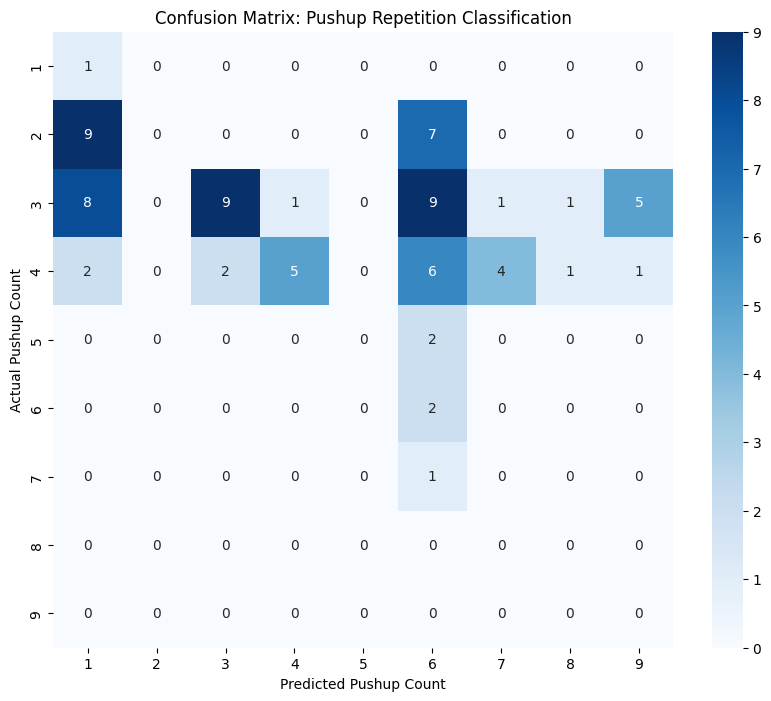


SUMMARY
Total videos:         77
Correct:              17
Incorrect:                60

ACCURACY:             22.08%

Total time:           52.38s
Avg per video:        148.6ms
Min latency:          138.9ms
Max latency:          295.0ms


In [14]:
model = VideoResNetModel()
checkpoint = torch.load('best_video_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.to("mps")
_, _, _ = run_inference(model)

# Continuing learning at a lower learning rate

In [26]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

# 1. Re-initialize Model, Optimizer, and Scheduler
model = VideoResNetModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4) # Initial LR doesn't matter yet
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min')

# 2. Load the Checkpoint
checkpoint = torch.load('best_video_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# scheduler.load_state_dict(checkpoint['schedular_state_dict'])
left_off_epoch = checkpoint['epoch']
best_val_loss_so_far = checkpoint.get('best_val_loss', float('inf'))

model.to(device)

# We iterate through the param_groups to force a new LR
new_lr = 5e-5 
for param_group in optimizer.param_groups:
    param_group['lr'] = new_lr

print(f"Resuming from Epoch {left_off_epoch}. LR reset to {new_lr}")

Resuming from Epoch 29. LR reset to 5e-05


# PICK UP HERE TOMORROW - CONTINUE TRAINING WITH SLIGHTLY LOWER LEARNING RATE

In [27]:
# setting a manual seed for reproducibility

print(f"Using device: {device}\n")
model, train_losses, train_acces, val_losses, val_acces = train_model(
    model, 
    epochs = 30, 
    lr = 1e-5, 
    weight_decay = 5e-4, 
    start_epoch = left_off_epoch, 
    best_val_loss = best_val_loss_so_far
    )

Using device: mps

Train: 66 videos, Val: 16 videos

Got dataloaders.

Go time. Let the training commence.

Loss on batch 0: 1.4939
Loss on batch 1: 1.6236
Loss on batch 2: 1.5860
Loss on batch 3: 1.3730
Loss on batch 4: 1.5401
Loss on batch 5: 1.8942
Loss on batch 6: 2.0229
Loss on batch 7: 1.8432
Loss on batch 8: 1.7422
Loss on batch 9: 1.4806
Loss on batch 10: 1.5821
Loss on batch 11: 1.9734
Loss on batch 12: 1.5439
Loss on batch 13: 2.3419
Sample Preds: [4 3 3 9 3]
Sample Preds: [3 3 1 3 4]
Sample Preds: [6 1 6 7 4]
Sample Preds: [1]
Epoch 29/58 | LR: 1.0e-05 | Train Loss: 1.7172, Train Acc: 0.64 | Val Loss: 1.9717, Val Acc: 0.25 | RAM: 0.82GB | Weight Norm: 26.211
Loss on batch 0: 1.7581
Loss on batch 1: 1.9094
Loss on batch 2: 1.8692
Loss on batch 3: 1.5548
Loss on batch 4: 1.3226
Loss on batch 5: 1.6721
Loss on batch 6: 1.9113
Loss on batch 7: 1.8638
Loss on batch 8: 1.6243
Loss on batch 9: 1.8687
Loss on batch 10: 1.9364
Loss on batch 11: 1.5082
Loss on batch 12: 1.7780
Loss on

KeyboardInterrupt: 

<!-- lowering weight decay -->

In [ ]:
# # More comprehensive model evaluation (no transformations)
# full_dataset = VideoDataset('./video-data')

# eval_loader = DataLoader(
#         full_dataset,
#         batch_size= 5,
#         shuffle = False,
#         num_workers = 0,
#         collate_fn = collate_fn
#         )

# eval_loss, eval_acc = evaluate(model_1, eval_loader, nn.MSELoss(), "mps", print_predictions = False)
# print(f"Model 1 --- Val Loss: {eval_loss:.4f}, Val Acc: {eval_acc:.2f}")
# eval_loss, eval_acc = evaluate(model_2, eval_loader, nn.MSELoss(), "mps", print_predictions = False)
# print(f"Model 2 --- Val Loss: {eval_loss:.4f}, Val Acc: {eval_acc:.2f}")

# Evaluate and report results

In [43]:
current = model
previous_best = VideoResNetModel()
checkpoint = torch.load('best_video_model.pth')
previous_best.load_state_dict(checkpoint['model_state_dict'])
previous_best.to("mps")
current.to("mps")
_, _, _ = run_inference(current)
_, _, _ = run_inference(previous_best)

Using device: mps

Running inference on 77 test videos...


✓  pred=2  true=2  |  2_sadfasjldkfjaseifj.mp4
✗  pred=3  true=2  |  2_sdafkjaslkclaksdjkas.mp4
✓  pred=4  true=4  |  4_kling_20251206_Text_to_Video_Generate_a_28_0.mp4
✓  pred=3  true=3  |  3_kling_dskfseu.mp4
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_190_0.mp4
✓  pred=3  true=3  |  3_kling_kdjflaskdjf.mp4
✗  pred=4  true=2  |  2_dsalkfjalwkenlke.mp4
✓  pred=3  true=3  |  3_dsjlaeijlksjdfie.mp4
✓  pred=3  true=3  |  3_kling_20251205_Text_to_Video_On_a_playg_5028_0.mp4
✓  pred=4  true=4  |  4_sadlfkjlknewkjejk.mp4
✓  pred=3  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_2.mp4
✓  pred=4  true=4  |  4_kling_20251209_Text_to_Video_Generate_a_561_1.mp4
✓  pred=2  true=2  |  2_difficult_2.mp4
✗  pred=4  true=3  |  3_sdlkjslndflkseijlkjef.mp4
✓  pred=3  true=3  |  3_kling_20251206_Text_to_Video_Generate_a_315_0.mp4
✗  pred=4  true=6  |  6_dfjewaijsldkjfsaef.mp4
✓  pred=4  true=4  |  4_kling_20251209_

## TODO 6

Include any code which you feel is useful for evaluating your model performance below.

In [15]:
# Loading the best model from all epochs of training, saved as a checkpoint

model = VideoResNetModel() 
checkpoint = torch.load('best_video_model.pth', map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['model_state_dict'])

# (Optional) If resuming training:
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
# start_epoch = checkpoint['epoch'] + 1
model.eval() # Set to evaluation mode for testing
print(f"Successfully loaded model from epoch {checkpoint['epoch']}")

Successfully loaded model from epoch 29


In [ ]:
# for plotting loss and accuracy curves

import matplotlib.pyplot as plt

def running_avgs(list_in):
    running_avgs = []
    for i, _ in enumerate(list_in):
        x = sum(list_in[:i+1]) / len(list_in[:i+1])
        running_avgs.append(x)

    return running_avgs

def eval_plots(loss, acc, loss_title = "Average training loss per epoch", acc_title = "Training accuracy per epoch"):
    fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(8, 4))

    # Plot data on the first axis (left plot)
    ax1.plot(loss)
    ax1.set_title(loss_title)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # Plot data on the second axis (right plot)
    ax2.plot(acc)
    ax2.set_title(acc_title)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")

    # Automatically adjust subplot parameters for a tight layout
    plt.tight_layout()

    # Display the figure
    plt.show()

def report_training_results(train_losses, train_acces, val_losses, val_acces):
    
    eval_plots(
        running_avgs(train_losses), 
        running_avgs(train_acces), 
        "Running average training loss, per epoch", 
        "Running average training accuracy, per epoch" 
        )
    eval_plots(
        running_avgs(val_losses), 
        running_avgs(val_acces), 
        "Running average evaluation loss, per epoch", 
        "Running average evaluation accuracy, per epoch"
        )


In [ ]:
# print what the model looks like
model

In [ ]:
# More comprehensive model evaluation (no transformations)
full_dataset = VideoDataset('./video-data')

eval_loader = DataLoader(
        full_dataset,
        batch_size= 5,
        shuffle = False,
        num_workers = 0,
        collate_fn = collate_fn
        )

model.to("mps")
eval_loss, eval_acc = evaluate(model, eval_loader, nn.CrossEntropyLoss(), "mps", print_predictions = True)
print(f"Val Loss: {eval_loss:.4f}, Val Acc: {eval_acc:.2f}")

In [ ]:
report_training_results(train_losses, train_acces, val_losses, val_acces)

In [ ]:
# show diagram of model
from torchview import draw_graph
model_for_graph = VideoResNetModel()
# You must provide a dummy input so it can trace the shapes
model_graph = draw_graph(
    model_for_graph, 
    input_size=(1, 3, 100, 224, 224), 
    expand_nested=True, 
    graph_dir="LR"
    )
model_graph.visual_graph

# trying to get a sense of what my augmented data looks like

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# def visualize_transformed_video(video_tensor, num_frames=5):
#     """
#     video_tensor: Tensor of shape (C, T, H, W)
#     num_frames: How many frames from the sequence to display
#     """
#     # 1. Move to CPU and Permute to (T, H, W, C) for plotting
#     # [C, T, H, W] -> [T, H, W, C]
#     video = video_tensor.permute(1, 2, 3, 0).cpu().numpy()
    
#     # 2. Denormalize
#     # These are the ImageNet constants you used in your transform
#     mean = np.array([0.485, 0.456, 0.406])
#     std = np.array([0.229, 0.224, 0.225])
#     video = (video * std) + mean
#     # video = np.clip(video, 0, 1) # Ensure values are within [0, 1]
    
#     # 3. Select frames to show (evenly spaced)
#     total_frames = video.shape[0]
#     indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
#     # 4. Plot
#     fig, axes = plt.subplots(1, num_frames, figsize=(20, 5))
#     for i, idx in enumerate(indices):
#         axes[i].imshow(video[idx])
#         axes[i].set_title(f"Frame {idx}")
#         axes[i].axis('off')
#     plt.show()

In [ ]:
# # Grab one batch from your training loader
# frames_batch, labels_batch = next(iter(val_loader))

# print(f"Viewing video with label: {labels_batch[0]}")
# visualize_transformed_video(frames_batch[0], num_frames=10)
# visualize_transformed_video(frames_batch[1], num_frames=10)
# visualize_transformed_video(frames_batch[2], num_frames=10)
# visualize_transformed_video(frames_batch[3], num_frames=10)
# visualize_transformed_video(frames_batch[4], num_frames=10)

# Hugging Face

It is a requirement of this assignment that you submit your trained model to a repo on Hugging Face, and make it publicly available. Below, we provide code which should help you do this.

## TODO 7

Upload your model to HuggingFace

Install the dependencies:

In [ ]:
%pip install huggingface_hub

You'll now need to log in to Hugging Face via the command line. To do this, you'll need to generate a token on your Hugging Face account. To generate a token, run the below command, and click on the link which appears.

In [ ]:
%hf auth login

The below code will only run if you have already trained a model with variable name 'model'.

The below code will take your trained model, and upload it to a *public* HuggingFace repo in your account called "mv-final-assignment".

(Note - in this example, we have set 'private=False' in the upload_to_hub method. This makes your model public).

You should double-check that your model is in fact public. To do that, you can navigate (in an incognito tab, in a browser) to https://huggingface.co/YOUR_USERNAME/YOUR_MODEL_NAME and see if that page loads. If your model is public, it will. (Simply being able to run the below code will not guarantee that your model is in fact public, because, you have now authenticated yourself with the huggingface CLI).

In [17]:
# YOUR HUGGING FACE USERNAME BELOW
hf_username = 'jjmoncus1'
# model = previous_best

In [18]:
import torch
import torch.nn as nn
from huggingface_hub import HfApi, hf_hub_download


def save_model(model, path="model.pt"):
    """Save the model weights to a file."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def upload_to_hub(local_path="model.pt", repo_id=f"{hf_username}/mv-final-assignment"):
    """
    Upload model to Hugging Face Hub.

    Args:
        local_path: Path to your saved model file
        repo_id: Your repo in format "username/model-name"
    """
    api = HfApi()

    # Create the repo first (if it already exists, this will just skip)
    api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        exist_ok=True,  # Don't error if it already exists
        private=False,  # Make it public so TAs can access
    )

    # Now upload the file
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo="model.pt",
        repo_id=repo_id,
        repo_type="model",
    )

    print(f"Model uploaded to https://huggingface.co/{repo_id}")


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":

    save_model(model, "mv-final-assignment.pt")

    upload_to_hub("mv-final-assignment.pt", f"{hf_username}/mv-final-assignment")


Model saved to mv-final-assignment.pt


Processing Files (1 / 1): 100%|██████████| 46.9MB / 46.9MB, 6.69MB/s  
New Data Upload: 100%|██████████| 3.84MB / 3.84MB, 3.84MB/s  


Model uploaded to https://huggingface.co/jjmoncus1/mv-final-assignment
